In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from collections import defaultdict


In [68]:
def gen_figure(model_f1_scores, bert_f1, dataset, sota_f1=None):
    shots_10 = [0,5,10,25,50,100,200,300,400,500]
    shots_9 = [5,10,25,50,100,200,300,400,500]
    
    all_markers = ['o', 's', '^', 'v', 'D', 'P', '*', 'X', 'h', '>', '<', '8', 'p', '|', '_']
    marker_map = dict(zip(model_f1_scores.keys(), all_markers[:len(model_f1_scores)]))

    base_models = set(m.split(" ", 1)[1] for m in model_f1_scores)
    unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))
    color_map_unique = {model: unique_colors(i) for i, model in enumerate(base_models)}

    # # Line styles and markers
    styles = {
        "Randomly": ("--", "o"),
        "Retrieved": ("-", "s")
    }

    # base_models = set(m.split(" ", 1)[1] for m in model_f1_scores)
    # print(base_models)
    # colors = plt.cm.tab20.colors
    # color_map = dict(zip(sorted(base_models), itertools.cycle(colors)))
    # print(color_map)

    # Plot
    plt.figure(figsize=(10, 6))
    for model, scores in model_f1_scores.items():
        prefix, base = model.split(" ", 1)
        linestyle, marker = styles[prefix]
        # marker = marker_map[model]
        color = color_map_unique[base]
        x_vals = list(range(len(scores))) if len(scores) == 10 else list(range(1, len(scores)+1))
        # x_vals = shots_10 if len(scores) == 10 else shots_9
        plt.plot(x_vals, scores, label=model, linestyle=linestyle, marker=marker, color=color)

    xtick_labels = shots_10
    plt.xticks(ticks=list(range(len(shots_10))), labels=xtick_labels)
    plt.axhline(bert_f1, linestyle=':', color='black', label=f'BERT baseline ({bert_f1})')
    # plt.axhline(sota_f1, linestyle='--', color='red', label=f'SOTA ({sota_f1})')

    plt.xlabel("# Shots")
    plt.ylabel("F1 Score")
    plt.title(f"Comparison on {dataset}")

    # Extract handles and labels from current plot
    handles, labels = plt.gca().get_legend_handles_labels()
    # Separate and reorder by category
    random = [(h, l) for h, l in zip(handles, labels) if 'Randomly' in l]
    retrieved = [(h, l) for h, l in zip(handles, labels) if 'Retrieved' in l]

    # Reorder so Randomly and Retrieved are grouped
    ordered_handles = [h for h, _ in random] + [h for h, _ in retrieved]
    ordered_labels = [l for _, l in random] + [l for _, l in retrieved]

    # Create two-column legend
    plt.legend(ordered_handles, ordered_labels, ncols=2)
    # plt.legend(loc="best", fontsize='small', ncols=2, reverse=True)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [56]:
bert_f1s = {
    'MIT_Movie': 61.17,
    'MIT_Res': 78.77,
    'CoNLL2003': 87.92,
    'WNUT2007': 50.30
}

data = {
    'MIT_Movie': {
        "Randomly Qwen-72B": [39.63, 58.37, 60.68, 64.66, 66.27, 66.37, 66.92, 67.03, 67.03, 68.09],
        "Retrieved Qwen-72B": [64.94, 65.80, 66.27, 67.79, 68.92, 68.98, 69.23, 70.17, 71.37],
        "Randomly DeepSeekV3": [53.93, 56.76, 66.18, 67.18, 67.22, 69.25, 70.29, 70.48, 71.17, 72.19],
        "Retrieved DeepSeekV3": [68.82, 69.79, 70.34, 70.91, 71.26, 72.64, 72.27, 73.05, 73.23],
        "Randomly GPT-4o" : [59.32, 63.82, 63.91, 64.70, 65.64, 65.87, 66.63, 67.48, 70.29, 72.11],
        "Retrieved GPT-4o" : [66.56, 68.26, 68.70, 69.37, 69.96, 70.46, 71.39, 72.14, 72.88],
        "Randomly Llama3.1-70B": [42.42, 50.94, 53.19, 56.86, 58.43, 64.21, 64.96, 65.63, 65.63, 68.45],
        "Retrieved Llama3.1-70B": [61.96, 63.16, 66.33, 66.67, 68.81, 69.04, 69.62, 69.70, 70.30],
        # "Randomly Qwen2.5-7B": [33.70, 52.30, 56.39, 57.33, 59.43, 60.80, 61.81, 63.04, 64.54],       # 9
        # "Retrieved Qwen2.5-7B": [64.67, 58.55, 60.94, 62.61, 62.86, 63.54, 63.56, 63.80, 64.37, 65.72], # 10
        # "Randomly LLama3.1-8B": [39.66, 51.36, 51.77, 52.84, 52.99, 53.03, 57.67, 60.08, 62.75],       # 9
        # "Retrieved LLama3.1-8B": [64.81, 48.72, 58.27, 61.48, 62.12, 62.50, 62.68, 63.63, 64.48, 64.08] # 10
    },
    'MIT_Res': {
        "Randomly Qwen-72B": [51.01, 66.29, 66.61, 67.31, 71.04, 73.54, 75.18, 76.72, 77.68, 79.96],
        "Retrieved Qwen-72B": [69.70, 73.76, 76.31, 76.96, 77.37, 78.24, 79.21, 79.38, 80.13],
        "Randomly DeepSeekV3": [51.26, 64.49, 65.45, 68.52, 74.90, 75.76, 76.02, 76.96, 77.20, 79.02],
        "Retrieved DeepSeekV3": [72.78, 76.66, 77.10, 77.66, 79.04, 79.66, 79.85, 79.94, 79.94],
        "Randomly GPT-4o": [58.10, 66.67, 68.51, 69.12, 70.66, 72.27, 73.14, 77.52, 77.99, 79.40],
        "Retrieved GPT-4o": [72.98, 73.26, 73.43, 73.45, 76.39, 77.14, 78.18, 78.23, 79.63],
        "Randomly Llama3.1-70B": [50.80, 58.71, 60.71, 62.71, 66.06, 70.35, 71.73, 72.74, 73.06, 74.75],
        "Retrieved Llama3.1-70B": [59.41, 64.09, 69.23, 71.70, 73.60, 74.27, 74.71, 75.13, 75.46],
        # "Randomly Qwen2.5-7B": [34.89, 47.28, 53.32, 54.41, 57.33, 63.03, 68.30, 69.75, 71.88, 72.77],
        # "Retrieved Qwen2.5-7B": [62.49, 64.77, 66.28, 69.75, 71.66, 72.17, 72.66, 73.82, 73.97],
        # "Randomly LLama3.1-8B": [36.76, 47.53, 53.55, 55.19, 57.91, 60.59, 63.00, 66.11, 69.71, 69.48],
        # "Retrieved LLama3.1-8B": [54.30, 57.63, 60.81, 62.89, 64.71, 67.27, 68.42, 69.71, 71.72]
    },
    'CoNLL2003': {
        "Randomly Qwen-72B": [62.43, 69.11, 73.75, 75.30, 83.27, 84.75, 85.62, 88.58, 89.95, 90.50],
        "Retrieved Qwen-72B": [78.27, 84.50, 87.66, 87.50, 89.43, 89.03, 89.62, 90.45, 91.10],
        "Randomly DeepSeekV3": [64.62, 69.65, 79.41, 79.45, 81.27, 86.62, 87.57, 88.01, 88.22, 88.22],
        "Retrieved DeepSeekV3": [83.99, 88.75, 89.58, 90.05, 90.05, 90.41, 90.15, 91.12, 95.59],
        "Randomly GPT-4o": [67.53, 76.28, 80.64, 84.30, 87.08, 87.41, 87.51, 87.70, 88.30, 88.84],
        "Retrieved GPT-4o": [77.99, 85.80, 86.94, 89.74, 89.83, 90.09, 90.23, 91.03, 91.14],
        "Randomly Llama3.1-70B": [50.39, 67.09, 69.34, 72.19, 72.29, 79.28, 80.91, 82.33, 85.81, 89.71],
        "Retrieved Llama3.1-70B": [67.57, 74.85, 75.41, 84.45, 85.42, 88.04, 88.60, 89.15, 90.85],
        # "Randomly Qwen2.5-7B": [42.88, 51.69, 54.34, 65.59, 68.42, 70.57, 77.69, 78.56, 79.42, 80.87],
        # "Retrieved Qwen2.5-7B": [63.90, 66.80, 67.86, 75.32, 78.68, 78.66, 79.06, 80.43, 81.36],
        # "Randomly LLama3.1-8B": [43.98, 50.82, 59.47, 65.08, 69.97, 72.49, 75.99, 75.69, 77.84, 79.58],
        # "Retrieved LLama3.1-8B": [59.41, 63.90, 68.16, 73.06, 75.99, 77.59, 76.29, 78.01, 80.84]
    },
    'WNUT2007': {
        "Randomly Qwen-72B": [37.46, 43.92, 47.70, 47.84, 49.50, 51.61, 50.50, 53.02, 54.03, 55.28],
        "Retrieved Qwen-72B": [46.50, 45.84, 47.30, 48.18, 49.36, 51.14, 52.57, 55.25, 55.00],
        "Randomly DeepSeekV3": [46.13, 47.61, 51.81, 52.67, 53.43, 53.52, 54.12, 53.83, 56.18, 57.99],
        "Retrieved DeepSeekV3": [48.51, 52.55, 53.51, 54.83, 54.46, 55.87, 55.98, 57.37, 57.37],
        "Randomly GPT-4o": [47.88, 52.30, 52.45, 53.94, 54.08, 54.83, 54.83, 56.27, 57.04, 57.53],
        "Retrieved GPT-4o": [55.27, 55.28, 55.41, 55.81, 56.39, 56.88, 57.19, 57.79, 59.18],
        "Randomly Llama3.1-70B": [30.98, 33.47, 37.97, 42.86, 46.51, 49.51, 50.98, 50.96, 51.71, 52.10],
        "Retrieved Llama3.1-70B": [36.99, 43.18, 46.34, 48.84, 49.53, 51.05, 51.36, 52.04, 52.71],
        # "Randomly Qwen2.5-7B": [14.49, 17.84, 18.35, 20.72, 26.39, 27.13, 29.25, 31.76, 32.35, 35.59],
        # "Retrieved Qwen2.5-7B": [17.84, 21.20, 21.83, 30.24, 32.48, 33.79, 33.87, 34.33, 34.88],
        # "Randomly LLama3.1-8B": [14.00, 16.67, 19.35, 23.24, 24.08, 28.77, 30.53, 31.66, 32.98, 33.18],
        # "Retrieved LLama3.1-8B": [19.31, 21.86, 23.56, 25.73, 27.14, 30.10, 32.34, 33.42, 34.83]
    }
}

/tmp/ipykernel_2718770/2149084425.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


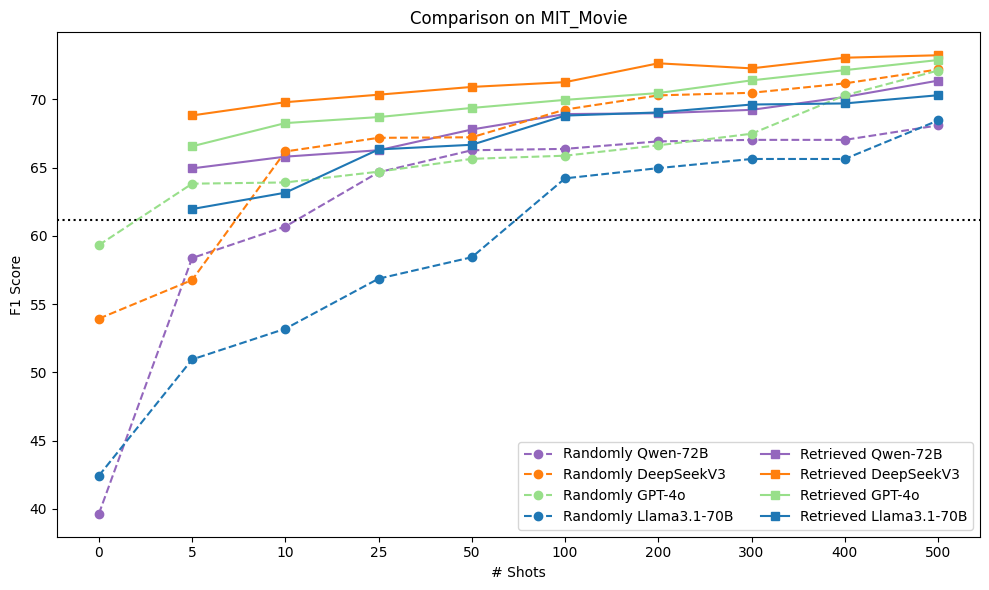

/tmp/ipykernel_2718770/2149084425.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


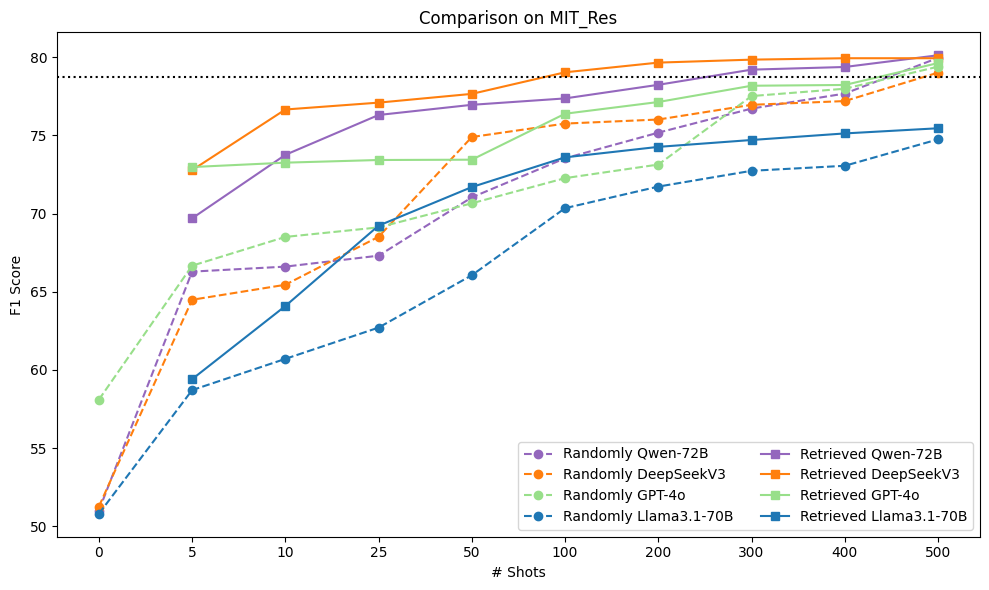

/tmp/ipykernel_2718770/2149084425.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


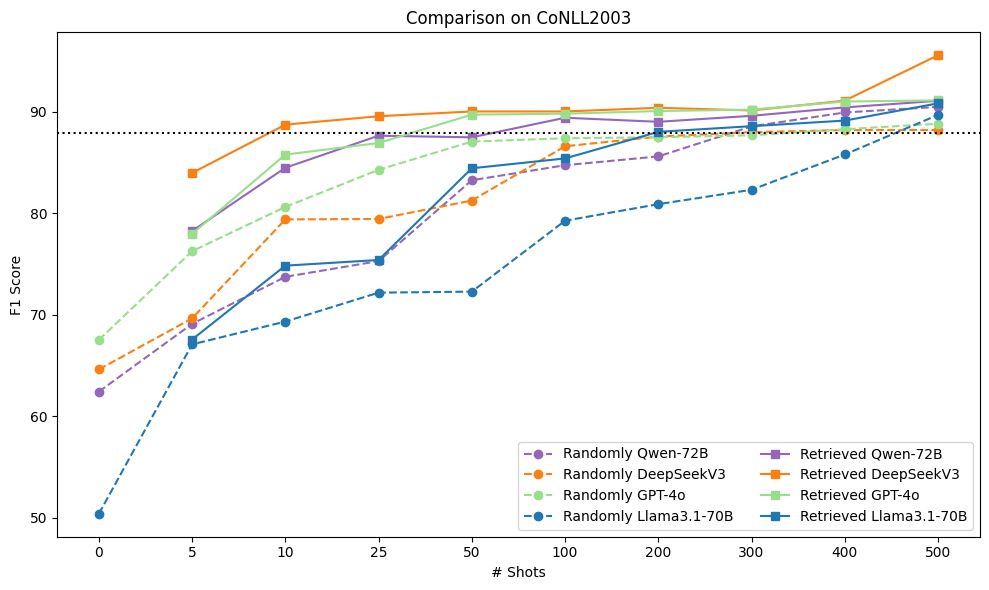

/tmp/ipykernel_2718770/2149084425.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


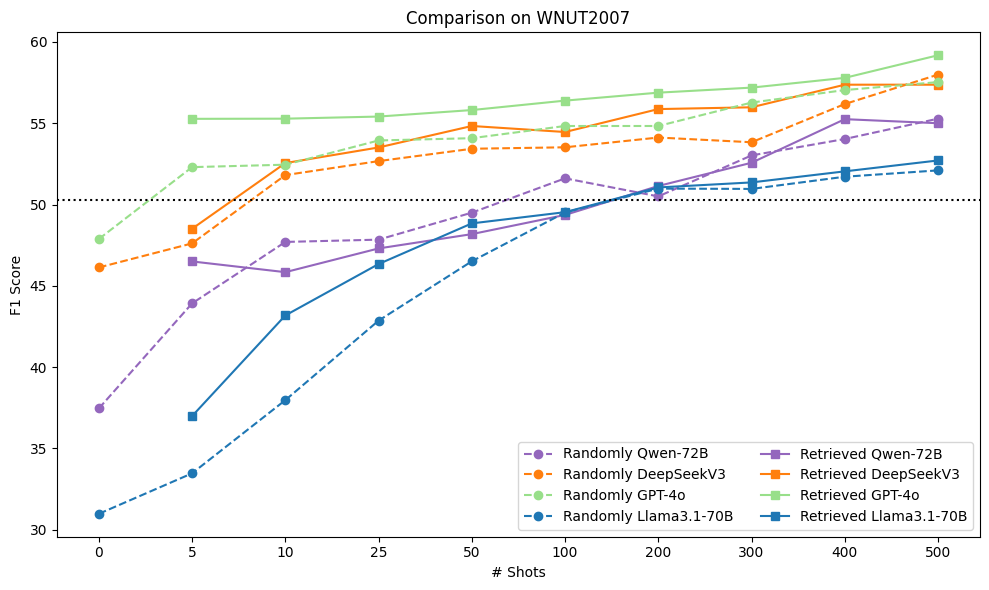

In [69]:
for dataset, f1_scores in data.items():
    bert_f1 = bert_f1s[dataset]

    gen_figure(f1_scores, bert_f1, dataset)

## MIT_Movie

/tmp/ipykernel_2718770/3189782658.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


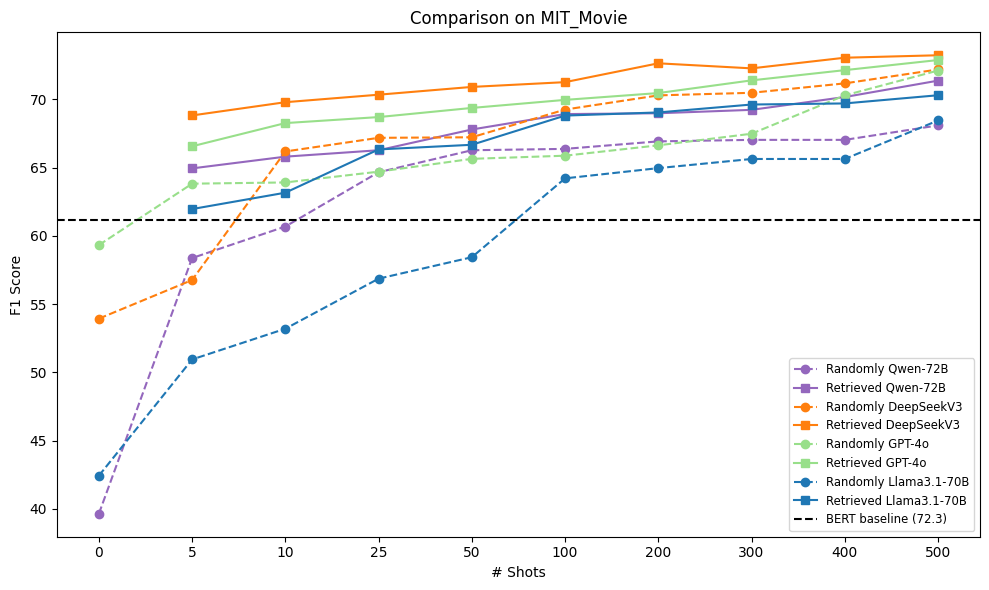

In [50]:
# Baseline values
bert_f1 = 61.17
# sota_f1 = 71.20

# Models and their corresponding F1 scores (MIT-Movie column values)
model_f1_scores = {
    "Randomly Qwen-72B": [39.63, 58.37, 60.68, 64.66, 66.27, 66.37, 66.92, 67.03, 67.03, 68.09],
    "Retrieved Qwen-72B": [64.94, 65.80, 66.27, 67.79, 68.92, 68.98, 69.23, 70.17, 71.37],
    "Randomly DeepSeekV3": [53.93, 56.76, 66.18, 67.18, 67.22, 69.25, 70.29, 70.48, 71.17, 72.19],
    "Retrieved DeepSeekV3": [68.82, 69.79, 70.34, 70.91, 71.26, 72.64, 72.27, 73.05, 73.23],
    "Randomly GPT-4o" : [59.32, 63.82, 63.91, 64.70, 65.64, 65.87, 66.63, 67.48, 70.29, 72.11],
    "Retrieved GPT-4o" : [66.56, 68.26, 68.70, 69.37, 69.96, 70.46, 71.39, 72.14, 72.88],
    "Randomly Llama3.1-70B": [42.42, 50.94, 53.19, 56.86, 58.43, 64.21, 64.96, 65.63, 65.63, 68.45],
    "Retrieved Llama3.1-70B": [61.96, 63.16, 66.33, 66.67, 68.81, 69.04, 69.62, 69.70, 70.30],
    # "Randomly Qwen2.5-7B": [33.70, 52.30, 56.39, 57.33, 59.43, 60.80, 61.81, 63.04, 64.54],       # 9
    # "Retrieved Qwen2.5-7B": [64.67, 58.55, 60.94, 62.61, 62.86, 63.54, 63.56, 63.80, 64.37, 65.72], # 10
    # "Randomly LLama3.1-8B": [39.66, 51.36, 51.77, 52.84, 52.99, 53.03, 57.67, 60.08, 62.75],       # 9
    # "Retrieved LLama3.1-8B": [64.81, 48.72, 58.27, 61.48, 62.12, 62.50, 62.68, 63.63, 64.48, 64.08] # 10
}

gen_figure(model_f1_scores, bert_f1, "MIT_Movie")


## MIT_Res

/tmp/ipykernel_2718770/3189782658.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


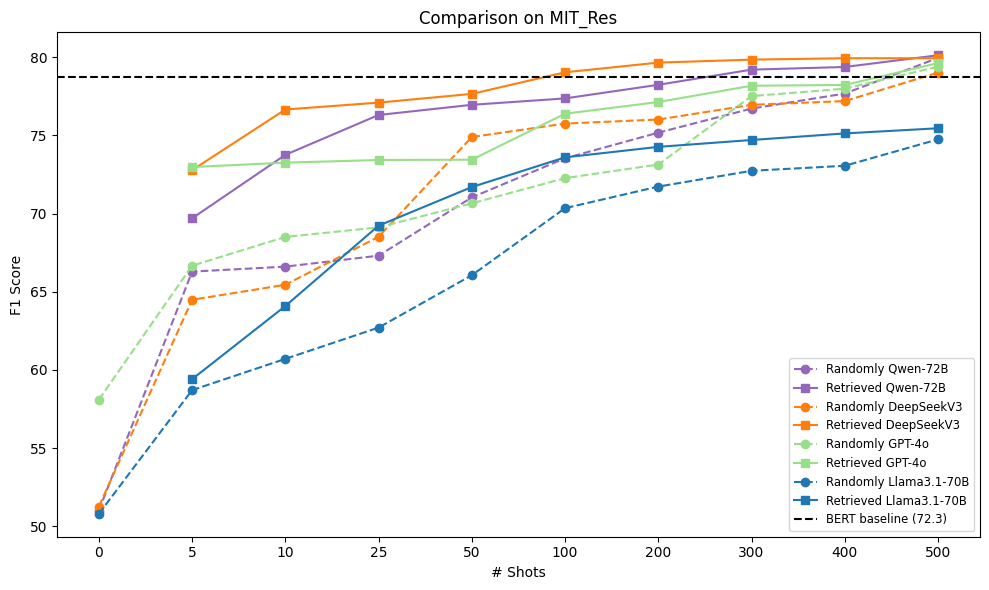

In [51]:

# Baseline values
bert_f1 = 78.77
# sota_f1 = 52.80

model_f1_scores = {
    "Randomly Qwen-72B": [51.01, 66.29, 66.61, 67.31, 71.04, 73.54, 75.18, 76.72, 77.68, 79.96],
    "Retrieved Qwen-72B": [69.70, 73.76, 76.31, 76.96, 77.37, 78.24, 79.21, 79.38, 80.13],
    "Randomly DeepSeekV3": [51.26, 64.49, 65.45, 68.52, 74.90, 75.76, 76.02, 76.96, 77.20, 79.02],
    "Retrieved DeepSeekV3": [72.78, 76.66, 77.10, 77.66, 79.04, 79.66, 79.85, 79.94, 79.94],
    "Randomly GPT-4o": [58.10, 66.67, 68.51, 69.12, 70.66, 72.27, 73.14, 77.52, 77.99, 79.40],
    "Retrieved GPT-4o": [72.98, 73.26, 73.43, 73.45, 76.39, 77.14, 78.18, 78.23, 79.63],
    "Randomly Llama3.1-70B": [50.80, 58.71, 60.71, 62.71, 66.06, 70.35, 71.73, 72.74, 73.06, 74.75],
    "Retrieved Llama3.1-70B": [59.41, 64.09, 69.23, 71.70, 73.60, 74.27, 74.71, 75.13, 75.46],
    # "Randomly Qwen2.5-7B": [34.89, 47.28, 53.32, 54.41, 57.33, 63.03, 68.30, 69.75, 71.88, 72.77],
    # "Retrieved Qwen2.5-7B": [62.49, 64.77, 66.28, 69.75, 71.66, 72.17, 72.66, 73.82, 73.97],
    # "Randomly LLama3.1-8B": [36.76, 47.53, 53.55, 55.19, 57.91, 60.59, 63.00, 66.11, 69.71, 69.48],
    # "Retrieved LLama3.1-8B": [54.30, 57.63, 60.81, 62.89, 64.71, 67.27, 68.42, 69.71, 71.72]
}

gen_figure(model_f1_scores, bert_f1, "MIT_Res")

## CoNLL2003

/tmp/ipykernel_2718770/3189782658.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


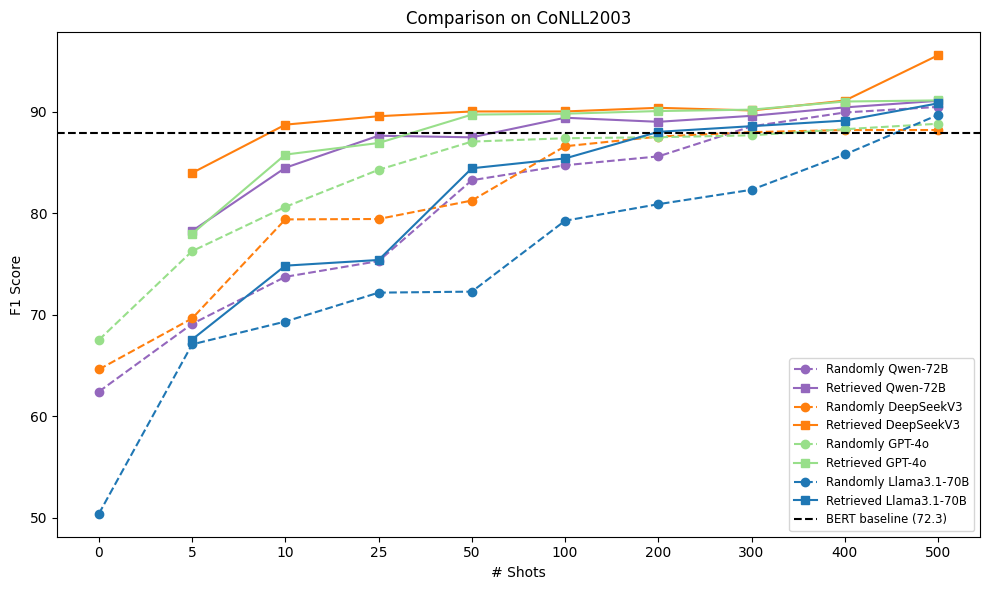

In [53]:
# Baseline values
bert_f1 = 87.92
# sota_f1 = 94.30

model_f1_scores = {
    "Randomly Qwen-72B": [62.43, 69.11, 73.75, 75.30, 83.27, 84.75, 85.62, 88.58, 89.95, 90.50],
    "Retrieved Qwen-72B": [78.27, 84.50, 87.66, 87.50, 89.43, 89.03, 89.62, 90.45, 91.10],
    "Randomly DeepSeekV3": [64.62, 69.65, 79.41, 79.45, 81.27, 86.62, 87.57, 88.01, 88.22, 88.22],
    "Retrieved DeepSeekV3": [83.99, 88.75, 89.58, 90.05, 90.05, 90.41, 90.15, 91.12, 95.59],
    "Randomly GPT-4o": [67.53, 76.28, 80.64, 84.30, 87.08, 87.41, 87.51, 87.70, 88.30, 88.84],
    "Retrieved GPT-4o": [77.99, 85.80, 86.94, 89.74, 89.83, 90.09, 90.23, 91.03, 91.14],
    "Randomly Llama3.1-70B": [50.39, 67.09, 69.34, 72.19, 72.29, 79.28, 80.91, 82.33, 85.81, 89.71],
    "Retrieved Llama3.1-70B": [67.57, 74.85, 75.41, 84.45, 85.42, 88.04, 88.60, 89.15, 90.85],
    # "Randomly Qwen2.5-7B": [42.88, 51.69, 54.34, 65.59, 68.42, 70.57, 77.69, 78.56, 79.42, 80.87],
    # "Retrieved Qwen2.5-7B": [63.90, 66.80, 67.86, 75.32, 78.68, 78.66, 79.06, 80.43, 81.36],
    # "Randomly LLama3.1-8B": [43.98, 50.82, 59.47, 65.08, 69.97, 72.49, 75.99, 75.69, 77.84, 79.58],
    # "Retrieved LLama3.1-8B": [59.41, 63.90, 68.16, 73.06, 75.99, 77.59, 76.29, 78.01, 80.84]
}

## CoNLL2003
gen_figure(model_f1_scores, bert_f1, "CoNLL2003")

## WNUT2017

/tmp/ipykernel_2718770/3189782658.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  unique_colors = plt.cm.get_cmap('tab20', len(model_f1_scores))


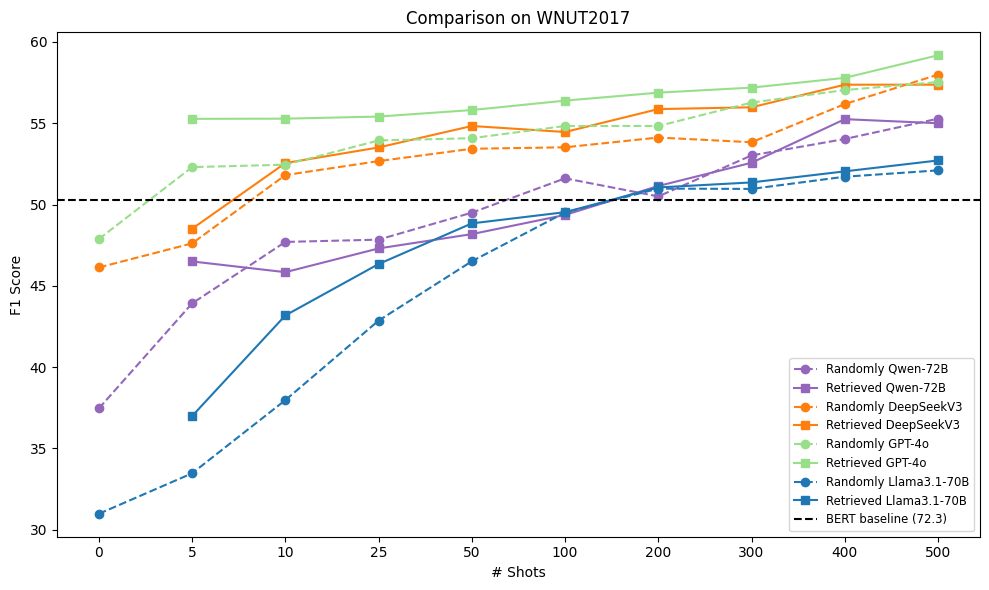

In [54]:
# Baseline values
bert_f1 = 50.30
# sota_f1 = 79.60

model_f1_scores = {
    "Randomly Qwen-72B": [37.46, 43.92, 47.70, 47.84, 49.50, 51.61, 50.50, 53.02, 54.03, 55.28],
    "Retrieved Qwen-72B": [46.50, 45.84, 47.30, 48.18, 49.36, 51.14, 52.57, 55.25, 55.00],
    "Randomly DeepSeekV3": [46.13, 47.61, 51.81, 52.67, 53.43, 53.52, 54.12, 53.83, 56.18, 57.99],
    "Retrieved DeepSeekV3": [48.51, 52.55, 53.51, 54.83, 54.46, 55.87, 55.98, 57.37, 57.37],
    "Randomly GPT-4o": [47.88, 52.30, 52.45, 53.94, 54.08, 54.83, 54.83, 56.27, 57.04, 57.53],
    "Retrieved GPT-4o": [55.27, 55.28, 55.41, 55.81, 56.39, 56.88, 57.19, 57.79, 59.18],
    "Randomly Llama3.1-70B": [30.98, 33.47, 37.97, 42.86, 46.51, 49.51, 50.98, 50.96, 51.71, 52.10],
    "Retrieved Llama3.1-70B": [36.99, 43.18, 46.34, 48.84, 49.53, 51.05, 51.36, 52.04, 52.71],
    # "Randomly Qwen2.5-7B": [14.49, 17.84, 18.35, 20.72, 26.39, 27.13, 29.25, 31.76, 32.35, 35.59],
    # "Retrieved Qwen2.5-7B": [17.84, 21.20, 21.83, 30.24, 32.48, 33.79, 33.87, 34.33, 34.88],
    # "Randomly LLama3.1-8B": [14.00, 16.67, 19.35, 23.24, 24.08, 28.77, 30.53, 31.66, 32.98, 33.18],
    # "Retrieved LLama3.1-8B": [19.31, 21.86, 23.56, 25.73, 27.14, 30.10, 32.34, 33.42, 34.83]
}

## WNUT2017
gen_figure(model_f1_scores, bert_f1, "WNUT2017")

# Research Question部分内容

In [ ]:
data = {
    'AI': [0.7082, 0.7599, 0.7785, 0.7988, 0.8002, 0.8062, 0.8071, 0.8095, 0.8106, 0.8125],
    'Literature':  [0.7039, 0.753, 0.8027, 0.8296, 0.8313, 0.8371, 0.8404, 0.8396, 0.8405, 0.8397],
}
x_labels = ['500', '1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000']
x_labels = [str(x) for x in x_labels]

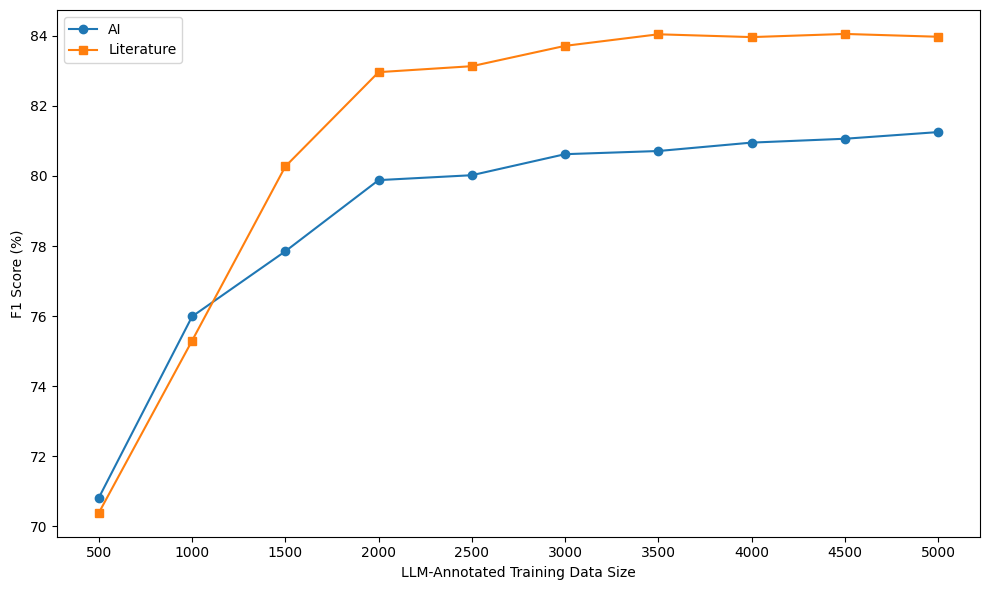

In [ ]:
import matplotlib.pyplot as plt

# 数据定义
data = {
    'AI': [0.7082, 0.7599, 0.7785, 0.7988, 0.8002, 0.8062, 0.8071, 0.8095, 0.8106, 0.8125],
    'Literature':  [0.7039, 0.753, 0.8027, 0.8296, 0.8313, 0.8371, 0.8404, 0.8396, 0.8405, 0.8397],
}
x_labels = ['500', '1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000']
x = range(len(x_labels))

# 基准线
sota_lines = {
    'AI': 70.20,
    'Literature': 73.51
}
iclms_lines = {
    'AI': 74.82,
    'Literature': 77.83
}

# 将数据乘以100
scaled_data = {
    'AI': [v * 100 for v in data['AI']],
    'Literature': [v * 100 for v in data['Literature']],
}

# 保存图片函数
def save_plot(domain, values, sota, iclms):
    plt.figure(figsize=(6, 4))
    plt.plot(x, values, marker='o', label='Our Method')
    plt.axhline(sota, color='red', linestyle='--', label=f'Previous SOTA ({sota})')
    plt.axhline(iclms, color='green', linestyle='--', label=f'ICL-MS ({iclms})')
    plt.xticks(x, x_labels)
    plt.xlabel('Training Data Size')
    plt.ylabel('F1 Score (%)')
    plt.title(f'{domain} Domain')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{domain.lower()}_trend.pdf')                     # for LaTeX (vector)
    plt.savefig(f'{domain.lower()}_trend.png', dpi=300)           # for high-res image
    plt.close()

# 绘图并保存
save_plot('AI', scaled_data['AI'], sota_lines['AI'], iclms_lines['AI'])
save_plot('Literature', scaled_data['Literature'], sota_lines['Literature'], iclms_lines['Literature'])

In [32]:
import matplotlib.pyplot as plt

# 数据定义
data = {
    'AI': [0.6978, 0.7599, 0.7785, 0.7988, 0.8002, 0.8062, 0.8071, 0.8095, 0.8106, 0.8125],
    'Literature':  [0.7039, 0.753, 0.8027, 0.8296, 0.8313, 0.8371, 0.8404, 0.8396, 0.8405, 0.8397],
}
x_labels = ['500', '1000', '1500', '2000', '2500', '3000', '3500', '4000', '4500', '5000']
x_labels = [str(int(label) // 100) for label in x_labels]
x = range(len(x_labels))

# 配置项
sota_lines = {
    'AI': 70.20,
    'Literature': 73.51
}
iclms_lines = {
    'AI': 74.82,
    'Literature': 77.83
}

# 将数据乘以100
scaled_data = {
    'AI': [v * 100 for v in data['AI']],
    'Literature': [v * 100 for v in data['Literature']],
}

# 画图 - AI
plt.figure(figsize=(6, 4))
plt.plot(x, scaled_data['AI'], marker='o', label='Our Method')
plt.axhline(sota_lines['AI'], color='red', linestyle='--', label='Previous SOTA (70.20)')
plt.axhline(iclms_lines['AI'], color='green', linestyle='--', label='ICL-MS (74.82)')
plt.xticks(x, x_labels, fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.ylim(65, 85)  # 固定 Y 轴范围
plt.xlabel('Training Data Size (×100)', fontsize=20, weight='bold')
plt.ylabel('F1 Score (%)', fontsize=20, weight='bold')
plt.title('AI', fontsize=18, weight='bold')
# plt.grid(True)
# plt.legend()
plt.tight_layout()
plt.savefig('./z-figure/ai_trend.pdf', dpi=300)
plt.close()

# 画图 - Literature
plt.figure(figsize=(6, 4))
plt.plot(x, scaled_data['Literature'], marker='o', label='ICA w/ EAR')
plt.axhline(sota_lines['Literature'], color='red', linestyle='--', label='Previous SOTA')
plt.axhline(iclms_lines['Literature'], color='green', linestyle='--', label='ICL-MS')
plt.xticks(x, x_labels, fontsize=20, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.ylim(65, 85)  # 固定 Y 轴范围
plt.xlabel('Training Data Size (×100)', fontsize=20, weight='bold')
# plt.ylabel('F1 Score (%)', fontsize=20)
plt.title('Literature', fontsize=18, weight='bold')
# plt.grid(True)
plt.legend(loc='lower right', fontsize=18)
plt.tight_layout()
plt.savefig('./z-figure/literature_trend.pdf', dpi=300)
plt.close()

## RQ2的图片

In [ ]:


x_labels = [0, 25, 50, 75, 100, 200, 300]

ai_values = 
literature_values = 

In [34]:
import matplotlib.pyplot as plt

# 数据定义
data = {
    'AI': [0.6781, 0.7214, 0.773, 0.7839, 0.7988, 0.8042, 0.8068],
    'Literature':  [0.6761, 0.7502, 0.7973, 0.8242, 0.8296, 0.8313, 0.8315],
}
x_labels = [0, 25, 50, 75, 100, 200, 300]
x = range(len(x_labels))

# 仅保留 SOTA
sota_lines = {
    'AI': 70.20,
    'Literature': 73.51
}

# 将数据乘以100
scaled_data = {
    'AI': [v * 100 for v in data['AI']],
    'Literature': [v * 100 for v in data['Literature']],
}

# =========================
# 图 1: AI
# =========================
plt.figure(figsize=(6, 4))
plt.plot(x, scaled_data['AI'], marker='o', label='Our Method', linewidth=2)
plt.axhline(sota_lines['AI'], color='red', linestyle='--', label='Previous SOTA (70.20)', linewidth=2)
plt.xticks(x, x_labels, fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.ylim(65, 85)
plt.xlabel('# Human-Annotated Samples', fontsize=20, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=20, fontweight='bold')
plt.title('AI', fontsize=20, fontweight='bold')
# plt.legend(loc='lower right', fontsize=16)
plt.tight_layout()
plt.savefig('./z-figure/human_annotated_study_ai.pdf', dpi=300)
plt.close()

# =========================
# 图 2: Literature
# =========================
plt.figure(figsize=(6, 4))
plt.plot(x, scaled_data['Literature'], marker='o', label='Our Method', linewidth=2)
plt.axhline(sota_lines['Literature'], color='red', linestyle='--', label='Previous SOTA', linewidth=2)
plt.xticks(x, x_labels, fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')
plt.ylim(65, 85)
plt.xlabel('# Human-Annotated Samples', fontsize=20, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=20, fontweight='bold')
plt.title('Literature', fontsize=20, fontweight='bold')
plt.legend(loc='lower right', fontsize=16)
plt.tight_layout()
plt.savefig('./z-figure/human_annotated_study_literature.pdf', dpi=300)
plt.close()

## RQ3

In [35]:
import matplotlib.pyplot as plt

# 数据
models = ['Qwen2.5-7B', 'Qwen2.5-32B', 'Qwen2.5-72B', 'DeepSeekV3', 'GPT-4o']
ai_values = [0.6983, 0.7457, 0.7651, 0.7988, 0.8078]
literature_values = [0.715, 0.7508, 0.7816, 0.8296, 0.8455]

# 乘以100
ai_values = [v * 100 for v in ai_values]
literature_values = [v * 100 for v in literature_values]

# 通用样式
bar_kwargs = dict(width=0.6, edgecolor='black')

# ========== 图1：AI ==========
plt.figure(figsize=(6, 4))
plt.bar(models, ai_values, **bar_kwargs)
plt.ylim(65, 90)
plt.xticks(rotation=15, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
plt.title('AI Domain', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./z-figure/llm_comparison_ai.pdf', dpi=300)
plt.close()

# ========== 图2：Literature ==========
plt.figure(figsize=(6, 4))
plt.bar(models, literature_values, **bar_kwargs)
plt.ylim(65, 90)
plt.xticks(rotation=15, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
plt.title('Literature Domain', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('./z-figure/llm_comparison_literature.pdf', dpi=300)
plt.close()

In [39]:
import matplotlib.pyplot as plt

# 数据
models = ['Qwen-7B', 'Qwen-32B', 'Qwen-72B', 'DeepSeekV3', 'GPT-4o']
ai_values = [0.6983, 0.7457, 0.7651, 0.7988, 0.8078]
literature_values = [0.715, 0.7508, 0.7816, 0.8296, 0.8455]

# SOTA 分数
sota_lines = {
    'AI': 70.20,
    'Literature': 73.51
}

# 转换为百分比
ai_values = [v * 100 for v in ai_values]
literature_values = [v * 100 for v in literature_values]

# 通用样式
bar_kwargs = dict(width=0.6, edgecolor='black')

# ========== 图1：AI ==========
plt.figure(figsize=(6, 4))
plt.bar(models, ai_values, **bar_kwargs)  # 不加 label
plt.axhline(sota_lines['AI'], color='red', linestyle='--', linewidth=2, label='Previous SOTA (70.20)')
plt.ylim(65, 90)
plt.xticks(rotation=15, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
plt.title('AI', fontsize=16, fontweight='bold')
# plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('./z-figure/llm_comparison_ai.pdf', dpi=300)
plt.close()

# ========== 图2：Literature ==========
plt.figure(figsize=(6, 4))
plt.bar(models, literature_values, **bar_kwargs)  # 不加 label
plt.axhline(sota_lines['Literature'], color='red', linestyle='--', linewidth=2, label='Previous SOTA')
plt.ylim(65, 90)
plt.xticks(rotation=15, fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
plt.title('Literature', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('./z-figure/llm_comparison_literature.pdf', dpi=300)
plt.close()